# Environmental analysis of ESB in the US

## Importing the librairies

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Setting the main variables

In [33]:
RAW_FILE = "../data/ESB_adoption_dataset_v8_update_august_2024.xlsx" # I renamed the file so pay attention to modify this line.
SHEET    = "1. District-level data"

MISSING_LOGICAL = {"Not applicable"}                         
MISSING_DATA    = {"Missing value", "Blank cell", "TBD", "N/A", "NA", "", " "}                      

In [34]:
df = (pd.read_excel(RAW_FILE, sheet_name=SHEET)
        .replace(list(MISSING_LOGICAL), "logical_na")
        .replace(list(MISSING_DATA), np.nan))

In [35]:
df = df.loc[:, 
            ['0a. Has committed ESBs?',
            '1a. State',
            '1f. City',
            '1g. State',
            '1h. ZIP code',
            '1p. Locale broad type (name)',
            '1q. Census Region',
            '1r. Census Division',
            '2a. Total number of buses',
            '3a. Number of ESBs committed ',
            '3b. Number of delivered or operating ESBs',
            '3c. Number of ESBs awarded',
            '3d. Number of ESBs ordered',
            '3e. Number of ESBs delivered',
            '3f. Number of ESBs operating',
            '3g. Number of batches',
            '3h. Size of batch 1',
            '3h. Size of batch 2',
            '3h. Size of batch 3',
            '3h. Size of batch 4',
            '3h. Size of batch 5',
            '3i. Percent of fleet that is electric',
            '3k. Utility/energy company involved 1',
            '3k. Utility/energy company involved 2',
            '3k. Utility/energy company involved 3',
            '3l. Other groups involved 1',
            '3l. Other groups involved 2',
            '3l. Other groups involved 3',
            '5h. Ozone concentration',
            '5i. Quartile: ozone concentration',
            '5l. Average rate of asthma among adults aged 18 and older',
            '5m. Quartile: average rate of asthma',
            '5o. EPA 2022 Clean School Bus Rebate Program prioritized school district?',
            '5p. EPA 2023 Clean School Bus Grant & Rebate Programs prioritized school district?',
            '6a. Has any expression of interest in ESBs?',
            '6f. Member of Climate Mayors Electric Vehicle Purchasing Collaborative?',
            '6g. School district sustainability commitment',
            '6h. District contains Generation180 Solar School?']
            ]


In [36]:
df.rename(columns={'1g. State': '1g. State Code'}, inplace=True)

In [37]:
df.columns = [col[4:] for col in df.columns]
print(df.columns)

Index(['Has committed ESBs?', 'State', 'City', 'State Code', 'ZIP code',
       'Locale broad type (name)', 'Census Region', 'Census Division',
       'Total number of buses', 'Number of ESBs committed ',
       'Number of delivered or operating ESBs', 'Number of ESBs awarded',
       'Number of ESBs ordered', 'Number of ESBs delivered',
       'Number of ESBs operating', 'Number of batches', 'Size of batch 1',
       'Size of batch 2', 'Size of batch 3', 'Size of batch 4',
       'Size of batch 5', 'Percent of fleet that is electric',
       'Utility/energy company involved 1',
       'Utility/energy company involved 2',
       'Utility/energy company involved 3', 'Other groups involved 1',
       'Other groups involved 2', 'Other groups involved 3',
       'Ozone concentration', 'Quartile: ozone concentration',
       'Average rate of asthma among adults aged 18 and older',
       'Quartile: average rate of asthma',
       'EPA 2022 Clean School Bus Rebate Program prioritized school 

In [38]:
# Strip leading and trailing whitespace
df.columns = df.columns.str.strip()
# Replace spaces with underscores and convert to lowercase
df.columns = df.columns.str.replace(' ', '_').str.lower()


In [39]:
df.head()

,has_committed_esbs?,state,city,state_code,zip_code,locale_broad_type_(name),census_region,census_division,total_number_of_buses,number_of_esbs_committed,...,ozone_concentration,quartile:_ozone_concentration,average_rate_of_asthma_among_adults_aged_18_and_older,quartile:_average_rate_of_asthma,epa_2022_clean_school_bus_rebate_program_prioritized_school_district?,epa_2023_clean_school_bus_grant_&_rebate_programs_prioritized_school_district?,has_any_expression_of_interest_in_esbs?,member_of_climate_mayors_electric_vehicle_purchasing_collaborative?,school_district_sustainability_commitment,district_contains_generation180_solar_school?
0,no,ALABAMA,Mt Meigs,AL,36057.0,Rural,South,East South Central,NaN,0,...,NaN,NaN,NaN,NaN,No,No,0.0,NaN,NaN,NaN
1,no,ALABAMA,Guntersville,AL,35976.0,Rural,South,East South Central,112.0,0,...,60.656726,3.0,0.099903,3.0,Yes,Yes,0.0,NaN,NaN,NaN
2,no,ALABAMA,Hoover,AL,35243.0,Urban,South,East South Central,189.0,0,...,66.566885,4.0,0.084228,1.0,No,No,0.0,NaN,NaN,NaN
3,no,ALABAMA,Madison,AL,35758.0,Suburban,South,East South Central,109.0,0,...,60.192694,3.0,0.089050,1.0,No,No,0.0,NaN,NaN,NaN
4,no,ALABAMA,Talladega,AL,35160.0,Town,South,East South Central,NaN,0,...,NaN,NaN,NaN,NaN,No,No,0.0,NaN,NaN,NaN


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19516 entries, 0 to 19515
Data columns (total 38 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   has_committed_esbs?                                                             19516 non-null  object 
 1   state                                                                           19516 non-null  object 
 2   city                                                                            19508 non-null  object 
 3   state_code                                                                      19516 non-null  object 
 4   zip_code                                                                        19508 non-null  float64
 5   locale_broad_type_(name)                                                        19516 non-null  object 
 6   census_region 

## Environmental data

(array([5.400e+01, 6.900e+01, 7.300e+01, 2.040e+02, 5.530e+02, 8.870e+02,
        1.468e+03, 1.933e+03, 2.226e+03, 2.204e+03, 1.327e+03, 7.790e+02,
        5.910e+02, 2.820e+02, 1.740e+02, 9.400e+01, 7.700e+01, 5.400e+01,
        2.700e+01, 1.200e+01, 9.000e+00, 4.000e+00, 7.000e+00, 8.000e+00,
        4.000e+00, 4.000e+00, 5.000e+00, 3.000e+00, 3.000e+00, 2.000e+00]),
 array([43.13494212, 44.99664031, 46.85833851, 48.7200367 , 50.58173489,
        52.44343309, 54.30513128, 56.16682947, 58.02852767, 59.89022586,
        61.75192405, 63.61362225, 65.47532044, 67.33701863, 69.19871683,
        71.06041502, 72.92211321, 74.78381141, 76.6455096 , 78.50720779,
        80.36890599, 82.23060418, 84.09230237, 85.95400057, 87.81569876,
        89.67739695, 91.53909515, 93.40079334, 95.26249153, 97.12418973,
        98.98588792]),
 <BarContainer object of 30 artists>)

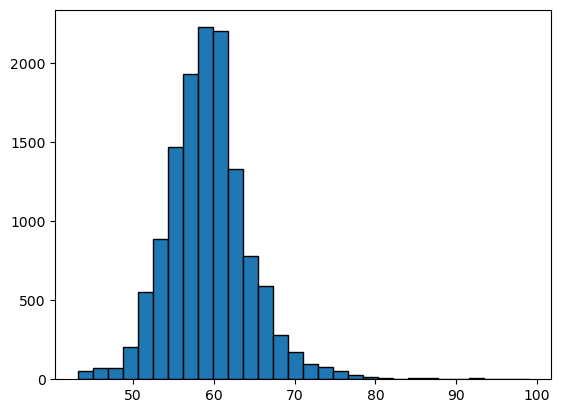

In [41]:
df['ozone_concentration'] = pd.to_numeric(df['ozone_concentration'], errors='coerce')
# Keeping the rows where 'ozone_concentration' is > 1
df = df[df['ozone_concentration'] > 1]
plt.hist(df['ozone_concentration'], bins=30, edgecolor='black')

What State have the most pollution and committed ESB ? 

/tmp/ipykernel_39358/480399945.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(sorted_states, rotation=90)


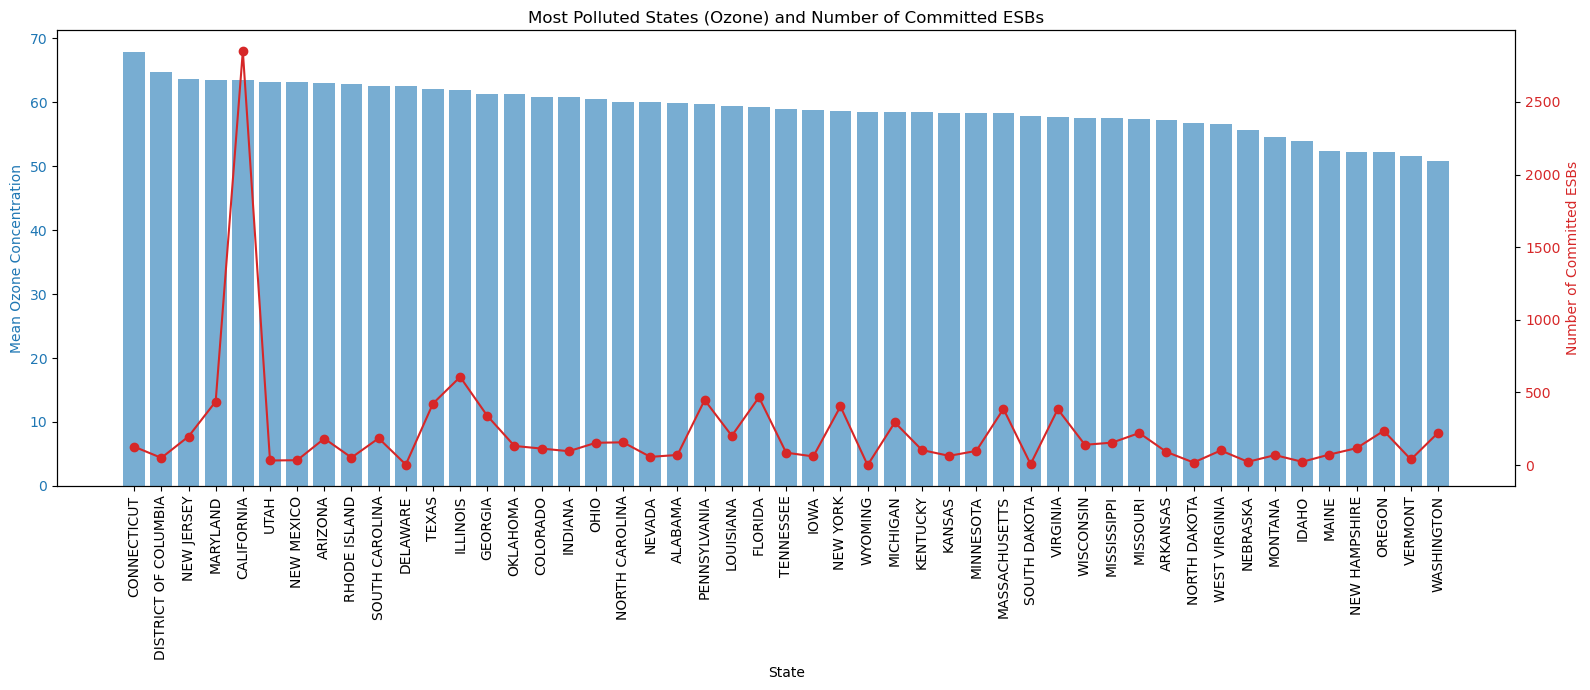

In [50]:
fig, ax1 = plt.subplots(figsize=(16, 7))

# Sort states by mean ozone concentration (descending)
sorted_states = state_ozone_means.sort_values(ascending=False).index

# Bar plot for ozone concentration (left y-axis)
color1 = 'tab:blue'
ax1.bar(sorted_states, state_ozone_means[sorted_states], color=color1, alpha=0.6, label='Mean Ozone Concentration')
ax1.set_ylabel('Mean Ozone Concentration', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticklabels(sorted_states, rotation=90)
ax1.set_xlabel('State')

# Line plot for number of committed ESBs (right y-axis)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.plot(sorted_states, state_committed_esb[sorted_states], color=color2, marker='o', label='Number of Committed ESBs')
ax2.set_ylabel('Number of Committed ESBs', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Most Polluted States (Ozone) and Number of Committed ESBs')
plt.tight_layout()
plt.show()

## Geographic data

Text(0, 0.5, 'Count')

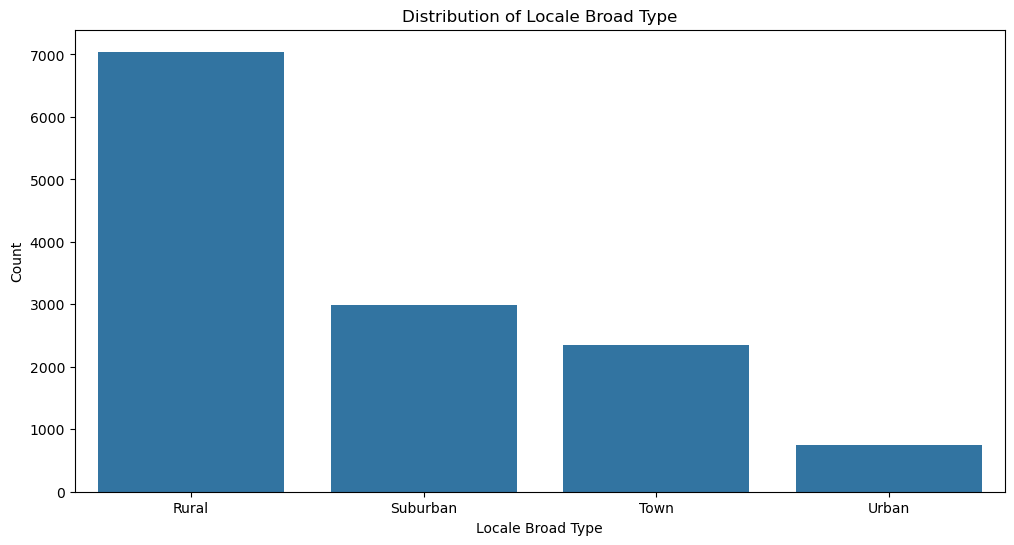

In [47]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='locale_broad_type_(name)', order=df['locale_broad_type_(name)'].value_counts().index)
plt.title('Distribution of Locale Broad Type')
plt.xlabel('Locale Broad Type')
plt.ylabel('Count')

Text(0, 0.5, 'Total Operating ESBs')

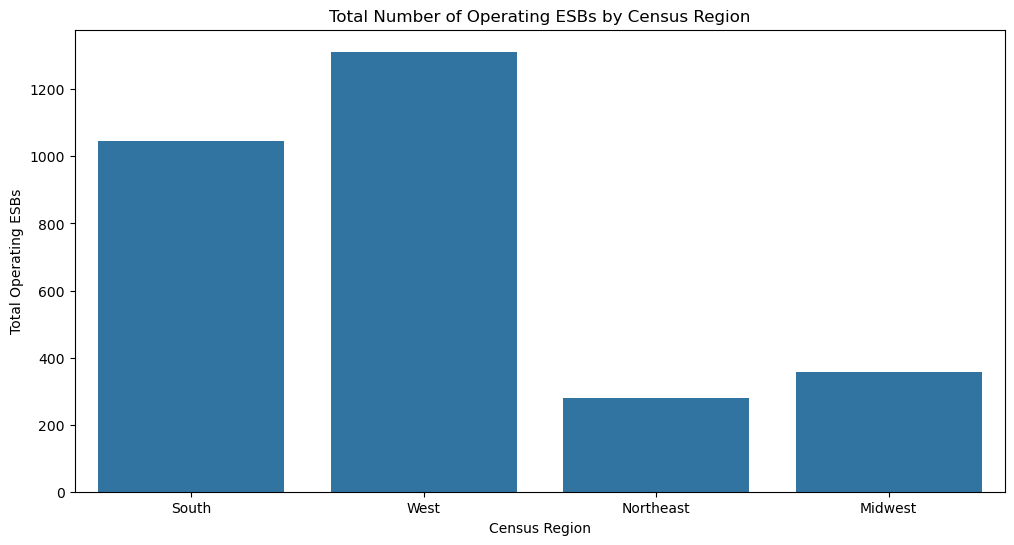

In [48]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='census_region', y='number_of_esbs_operating', estimator='sum', errorbar=None)
plt.title('Total Number of Operating ESBs by Census Region')
plt.xlabel('Census Region')
plt.ylabel('Total Operating ESBs')